## Как оценивать качество решения ML-задачи?

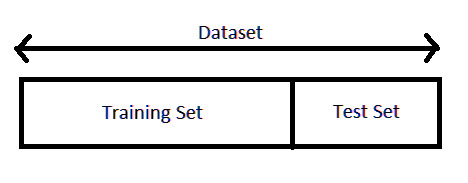

## Метрики задачи классификации

### Подготовка данных

Набор данных - [Breast Cancer Wisconsin](https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+(Diagnostic) для задачи бинарной классификации

Признаки рассчитаны по оцифрованному изображению тонкоигольной аспирационной биопсии тканей молочной железы.



In [ ]:
!pip -q install scikit-learn

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

In [ ]:
data = load_breast_cancer()

# 0 – "доброкачественный"
# 1 – "злокачественный", положительный класс означает интересующее событие
y = 1 - data["target"]
X = data["data"]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=2023, test_size=0.25)

In [ ]:
data

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0

In [ ]:
X_train

array([[1.272e+01, 1.767e+01, 8.098e+01, ..., 3.612e-02, 2.165e-01,
        6.025e-02],
       [9.876e+00, 1.940e+01, 6.395e+01, ..., 9.749e-02, 2.622e-01,
        8.490e-02],
       [9.847e+00, 1.568e+01, 6.300e+01, ..., 6.528e-02, 2.502e-01,
        9.209e-02],
       ...,
       [1.134e+01, 1.861e+01, 7.276e+01, ..., 8.542e-02, 3.060e-01,
        6.783e-02],
       [1.262e+01, 1.715e+01, 8.062e+01, ..., 9.851e-02, 3.270e-01,
        7.330e-02],
       [1.169e+01, 2.444e+01, 7.637e+01, ..., 1.308e-01, 2.803e-01,
        9.970e-02]])

DummyClassifier - baseline

In [ ]:
dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train, y_train);

Логистическая регрессия - более сложная модель

In [ ]:
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train);

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Accuracy

Accuracy (точность) - доля объектов, для которых мы правильно предсказали класс

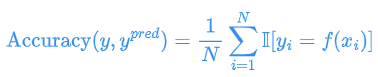

Данная метрика очень простая, но не лишена недостатков: она не учитывает дисбаланс классов.

Предположим, что мы решаем задачу классификации писем со спамом, и у нас в выборке 1000 объектов, из которых спам - 10 писем, а остальные 990 - не спам.

Тогда, взяв "модель", которая всегда классифицирует письмо как "не спам", мы автоматически получим accuracy = **0.99**, хотя сам классификатор не имеет никакой ценности.

Кроме того, иногда цена ошибки для разных классов отличается, например, в медицинской диагностике.



In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
y_pred_dummy = dummy_clf.predict(X_test)
accuracy_score(y_test, y_pred_dummy)

0.6293706293706294

In [ ]:
y_pred_log_reg = log_reg.predict(X_test)
accuracy_score(y_test, y_pred_log_reg)

0.9790209790209791

Рассмотрим более сложные метрики, позволяющие скорректировать недостатки Accuracy

### Precision & Recall

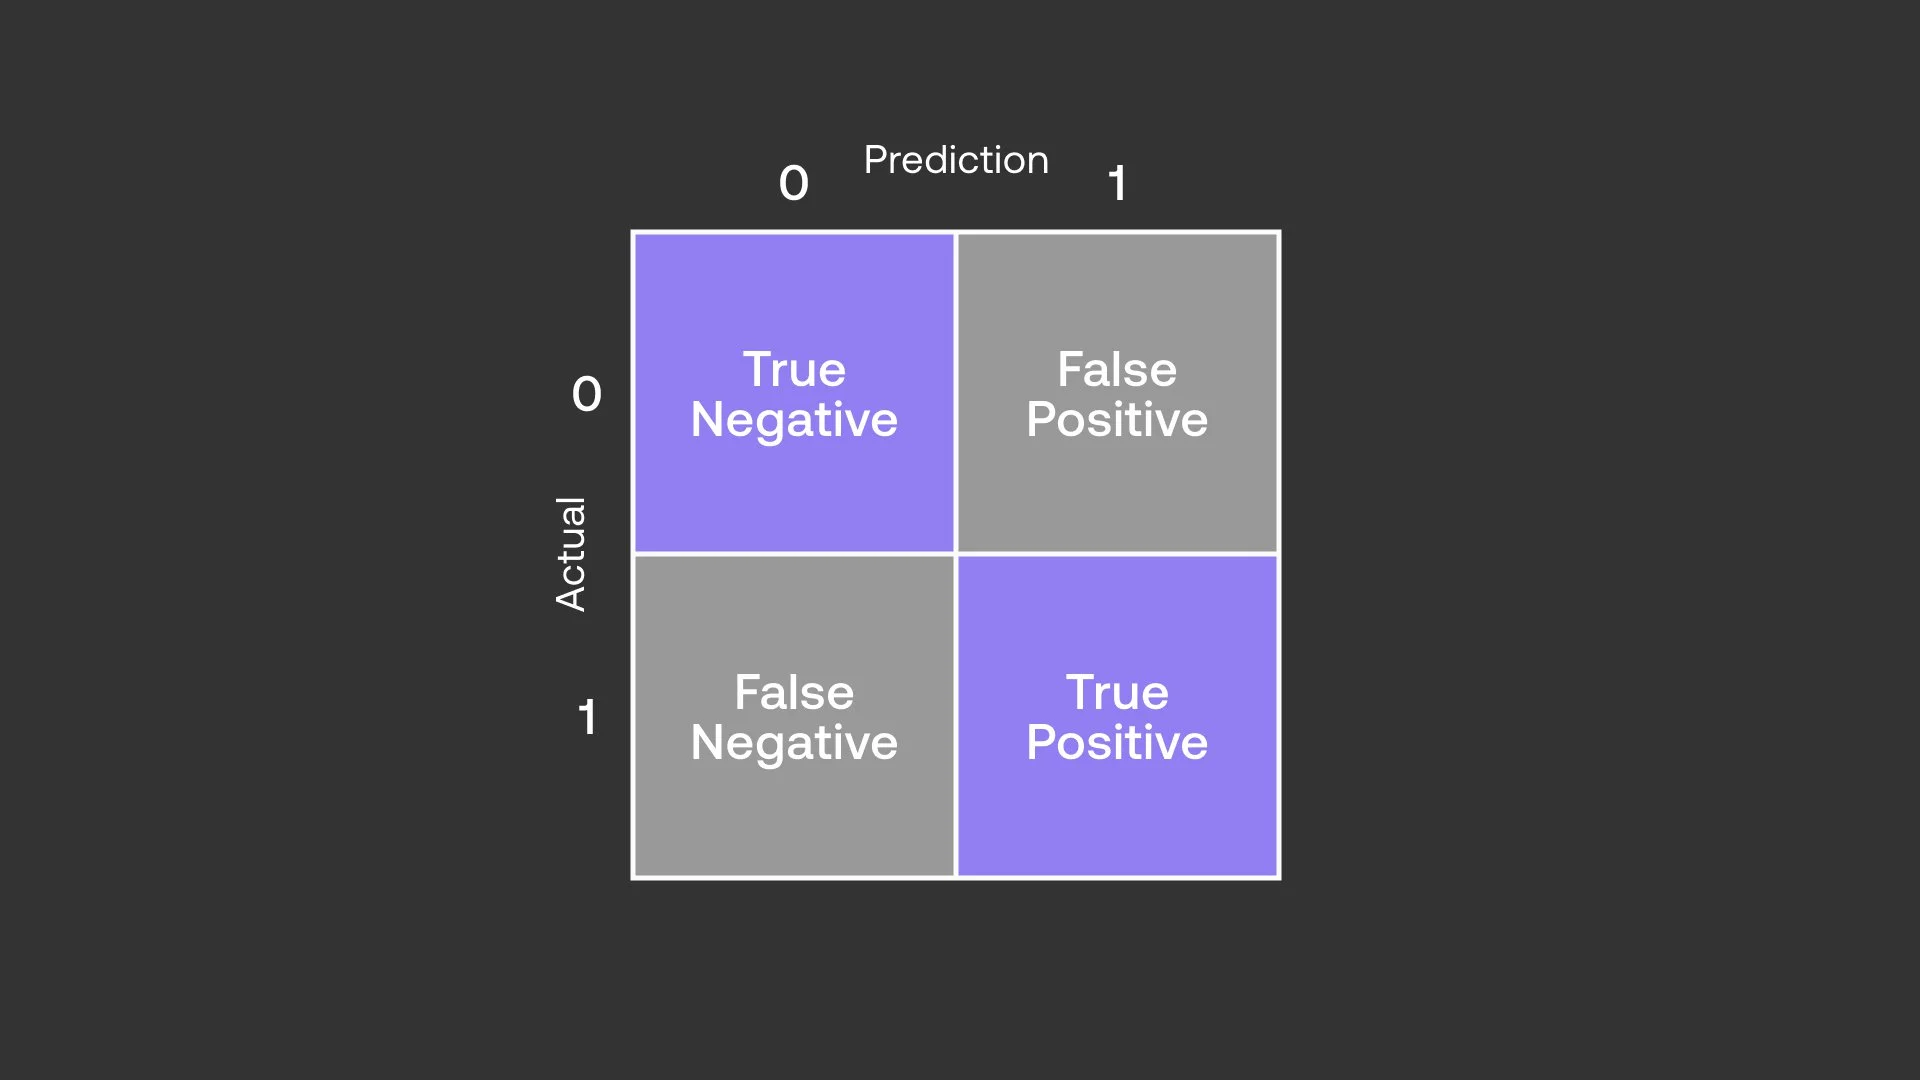

**TP** — истино-положительное решение;

**TN** — истино-отрицательное решение;

**FP** — ложно-положительное решение;

**FN** — ложно-отрицательное решение

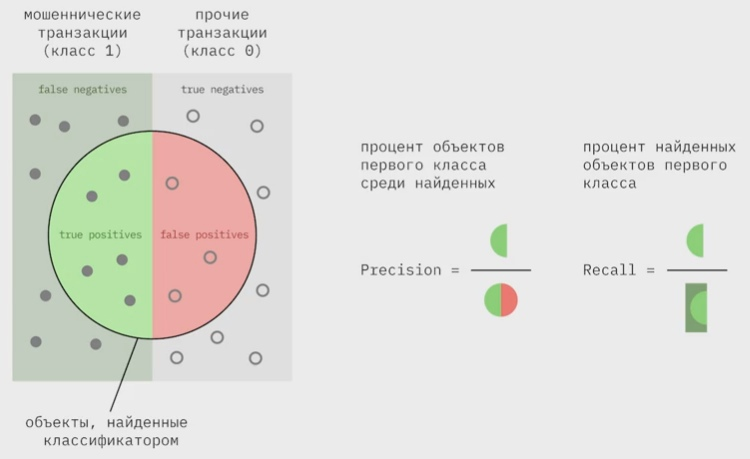

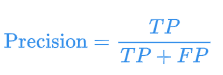

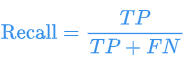

**Recall = True Positive Rate = Sensitivity**  - какой процент объектов класса 1 классифицировали правильно == "какую долю фактических положительных нашли"

**Precision** - какой процент объектов, отнесенных алгоритмом к классу 1, классифицировали правильно == "какая доля положительных решений верна"

In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score

In [ ]:
confusion_matrix(y_test, y_pred_dummy)

array([[90,  0],
       [53,  0]])

In [ ]:
confusion_matrix(y_test, y_pred_log_reg)

array([[88,  2],
       [ 1, 52]])

In [ ]:
print(f'Precision for Dummy Classificator: {precision_score(y_test, y_pred_dummy, zero_division=0)}')
print(f'Precision for Logistic regression: {precision_score(y_test, y_pred_log_reg, zero_division=0)}')

Precision for Dummy Classificator: 0.0
Precision for Logistic regression: 0.9629629629629629


In [ ]:
print(f'Recall for Dummy Classificator: {recall_score(y_test, y_pred_dummy)}')
print(f'Recall for Logistic regression: {recall_score(y_test, y_pred_log_reg)}')

Recall for Dummy Classificator: 0.0
Recall for Logistic regression: 0.9811320754716981


### F-мера

Более удобно, когда метрика выражена одним числом. F-мера - комбинация precision и recall. Она стремится к нулю, если точность или полнота стремится к нулю.

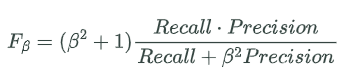

В случае, когда `beta = 1` precision и recall имеют одинаковый вклад в метрику. При `0 < beta < 1` больший вклад имеет precision, при `beta > 1` - recall

In [ ]:
from sklearn.metrics import f1_score, fbeta_score

In [ ]:
print(f'F1-score for Dummy Classificator: {f1_score(y_test, y_pred_dummy)}')
print(f'F1-score for Logistic regression: {f1_score(y_test, y_pred_log_reg)}')

F1-score for Dummy Classificator: 0.0
F1-score for Logistic regression: 0.9719626168224299


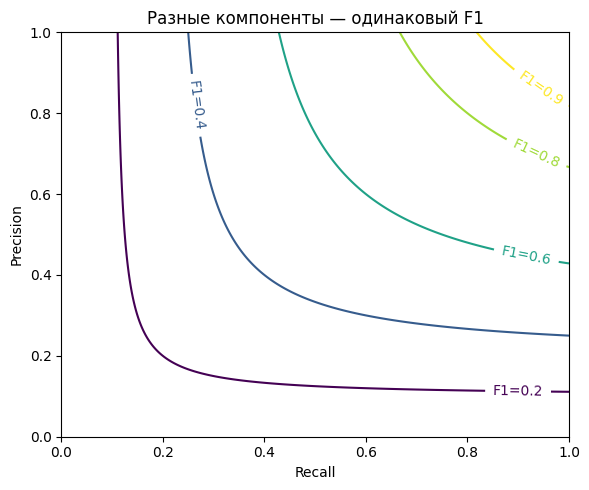

In [ ]:
p_grid, r_grid = np.meshgrid(np.linspace(0.001, 1, 250), np.linspace(0.001, 1, 250))
f_grid = 2 * p_grid * r_grid / (p_grid + r_grid)
fig, ax = plt.subplots(figsize=(6, 5))
contours = ax.contour(r_grid, p_grid, f_grid, levels=[0.2, 0.4, 0.6, 0.8, 0.9], cmap="viridis")
ax.clabel(contours, fmt="F1=%.1f")
ax.set(
    xlabel="Recall",
    ylabel="Precision",
    title="Разные компоненты — одинаковый F1",
    xlim=(0, 1),
    ylim=(0, 1)
)
plt.tight_layout()
plt.show()

In [ ]:
print(f'Fbeta for Dummy Classificator (recall bias): {fbeta_score(y_test, y_pred_dummy, beta=2)}')
print(f'Fbeta for Logistic regression (recall bias): {fbeta_score(y_test, y_pred_log_reg, beta=2)}')

Fbeta for Dummy Classificator (recall bias): 0.0
Fbeta for Logistic regression (recall bias): 0.9774436090225563


In [ ]:
print(f'Fbeta-score for Dummy Classificator (precision bias): {fbeta_score(y_test, y_pred_dummy, beta=0.5)}')
print(f'Fbeta-score for Logistic regression (precision bias): {fbeta_score(y_test, y_pred_log_reg, beta=0.5)}')

Fbeta-score for Dummy Classificator (precision bias): 0.0
Fbeta-score for Logistic regression (precision bias): 0.966542750929368


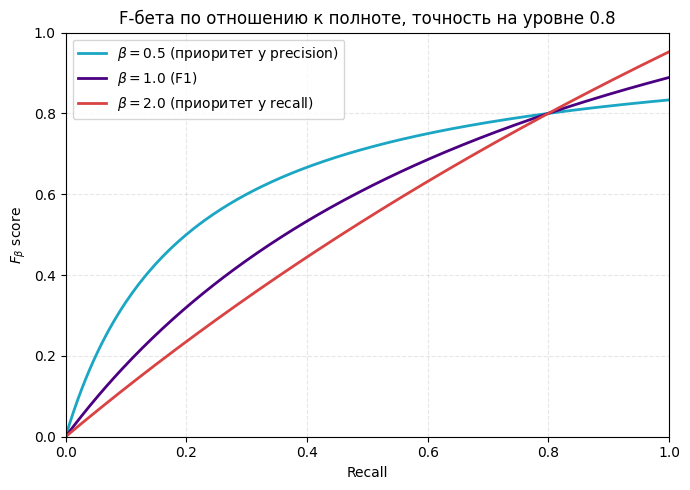

In [ ]:
precision = 0.8
recall = np.linspace(0, 1, 300)

betas = [0.5, 1.0, 2.0]
colors = ["#1ba6c4", "#4b0082", "#d94343"]
labels = [
    r"$\beta = 0.5$ (приоритет у precision)",
    r"$\beta = 1.0$ (F1)",
    r"$\beta = 2.0$ (приоритет у recall)",
]

with plt.style.context("default"):
    fig, ax = plt.subplots(figsize=(7, 5))

    for beta, color, label in zip(betas, colors, labels):
        f_beta = (1 + beta ** 2) * precision * recall / (beta ** 2 * precision + recall)
        ax.plot(recall, f_beta, color=color, linewidth=2, label=label)

    ax.set(xlabel="Recall", ylabel=r"$F_\beta$ score", xlim=(0, 1), ylim=(0, 1), title='F-бета по отношению к полноте, точность ​на уровне 0.8')
    ax.set_xticks(np.linspace(0, 1, 6))
    ax.set_yticks(np.linspace(0, 1, 6))

    ax.grid(linestyle="--", alpha=0.3)
    ax.legend(loc="upper left")

    plt.tight_layout()
    plt.show()

#### Немного о порогах классификации

Для оптимизации метрик можно перебрать пороги бинаризации при классификации (по умолчанию порог = 0.5), для каждого значения рассчитать precision и recall, а затем построить кривые метрик и выбрать оптимальное значение

In [ ]:
from sklearn.metrics import precision_recall_curve

In [ ]:
y_pred = log_reg.predict_proba(X_test)[:, 1]

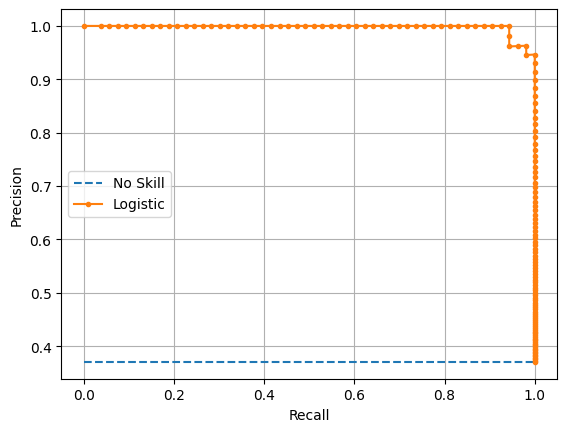

In [ ]:
precision, recall, thresholds = precision_recall_curve(y_test, y_pred)

no_skill = len(y_test[y_test == 1]) / len(y_test)

plt.plot([0,1], [no_skill, no_skill], linestyle='--', label='No Skill')
plt.plot(recall, precision, marker='.', label='Logistic')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.grid()
plt.show()

Для определения оптимального порога классификации можно использовать что-то вроде формулы:

$Expected Cost = (Cost_{FP} * FP) + (Cost_{FN} * FN)$

Где:
- $Cost_{FP}$: стоимость одной ошибки False Positive
- $Cost_{FN}$: стоимость одной ошибки False Negative  
- FP, FN: количество ошибок каждого типа при данном пороге

Оптимальный порог = argmin(Expected Cost) по всем возможным порогам

Правило большого пальца:
- Если $Cost_{FN}$ >> $Cost_{FP}$ (в 10+ раз): снижайте порог → ↑ Recall, жертвуете Precision
- Если $Cost_{FP}$ ≈ $Cost_{FN}$: порог ≈ 0.5 → балансируете Precision и Recall
- Если $Cost_{FP}$ >> $Cost_{FN}$: повышайте порог → ↑ Precision, жертвуете Recall

In [ ]:
def class_counts(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {"TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp)}

def decision_metrics(y_true, y_pred):
    counts = class_counts(y_true, y_pred)
    negatives = counts["TN"] + counts["FP"]
    positives = counts["TP"] + counts["FN"]
    return {**counts, "accuracy": accuracy_score(y_true, y_pred), "precision": precision_score(y_true, y_pred, zero_division=np.nan), "recall": recall_score(y_true, y_pred, zero_division=np.nan), "FPR": counts["FP"] / negatives if negatives else np.nan, "FNR": counts["FN"] / positives if positives else np.nan, "TNR": counts["TN"] / negatives if negatives else np.nan}

In [ ]:
import pandas as pd

In [ ]:
COST_FP = 1.0
COST_FN = 10.0
threshold_grid = np.linspace(0, 1, 101)
threshold_rows = []
for threshold in threshold_grid:
    pred = (y_pred >= threshold).astype(int)
    metrics = decision_metrics(y_test, pred)
    total_cost = COST_FP * metrics["FP"] + COST_FN * metrics["FN"]
    threshold_rows.append({"threshold": threshold, **metrics, "F1": f1_score(y_test, pred, zero_division=0), "positive_decisions": int(pred.sum()), "total_cost": total_cost, "mean_cost": total_cost / len(pred)})

threshold_table = pd.DataFrame(threshold_rows)
threshold_table.loc[threshold_table["threshold"].isin([0.1, 0.2, 0.3, 0.4, 0.5, 0.8]), ["threshold", "TP", "FP", "FN", "TN", "precision", "recall", "F1", "positive_decisions", "mean_cost"]].round(4)

,threshold,TP,FP,FN,TN,precision,recall,F1,positive_decisions,mean_cost
10,0.1,53,12,0,78,0.8154,1.0000,0.8983,65,0.0839
20,0.2,53,4,0,86,0.9298,1.0000,0.9636,57,0.0280
30,0.3,52,3,1,87,0.9455,0.9811,0.9630,55,0.0909
40,0.4,52,2,1,88,0.9630,0.9811,0.9720,54,0.0839
50,0.5,52,2,1,88,0.9630,0.9811,0.9720,54,0.0839
80,0.8,48,0,5,90,1.0000,0.9057,0.9505,48,0.3497


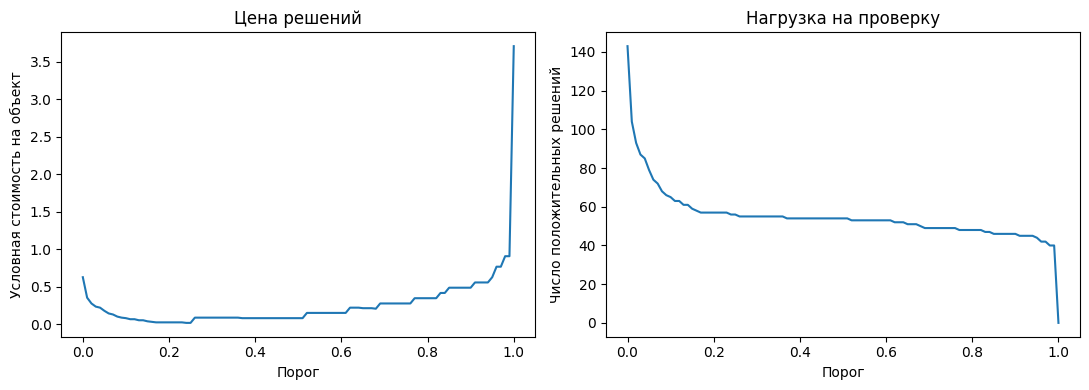

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(threshold_table["threshold"], threshold_table["mean_cost"])
axes[0].set(xlabel="Порог", ylabel="Условная стоимость на объект", title="Цена решений")
axes[1].plot(threshold_table["threshold"], threshold_table["positive_decisions"])
axes[1].set(xlabel="Порог", ylabel="Число положительных решений", title="Нагрузка на проверку")
plt.tight_layout()
plt.show()

#### Еще пример - антифрод

Банк сравнивает два варианта системы обнаружения мошеннических операций. Система принимает одно из двух решений: пропустить платёж или заблокировать его как подозрительный.

В выборке 10 000 платежей, из которых 100 действительно мошеннические.

Зададим условную стоимость ошибок:

- Каждый FP обходится банку в 10 денежных единиц: компенсация неудобства и обработка обращения клиента.
- Каждый FN приводит к невозмещённому убытку в 1 000 денежных единиц.

Правильным решениям назначим нулевую стоимость.

In [ ]:
cost_example = pd.DataFrame({"variant": ["A", "B"], "TP": [80, 90], "FP": [120, 300], "FN": [20, 10]})
cost_example["precision"] = cost_example["TP"] / (cost_example["TP"] + cost_example["FP"])
cost_example["recall"] = cost_example["TP"] / (cost_example["TP"] + cost_example["FN"])
cost_example["F1"] = 2 * cost_example["TP"] / (2 * cost_example["TP"] + cost_example["FP"] + cost_example["FN"])
cost_example["total_cost"] = 10 * cost_example["FP"] + 1000 * cost_example["FN"]
cost_example.round(4)

,variant,TP,FP,FN,precision,recall,F1,total_cost
0,A,80,120,20,0.4000,0.8,0.5333,21200
1,B,90,300,10,0.2308,0.9,0.3673,13000


F1 не знает цены ошибок, поэтому вариант с меньшим F1 может оказаться предпочтительнее для конкретной задачи!

### Matthews Correlation Coefficient (MCC)

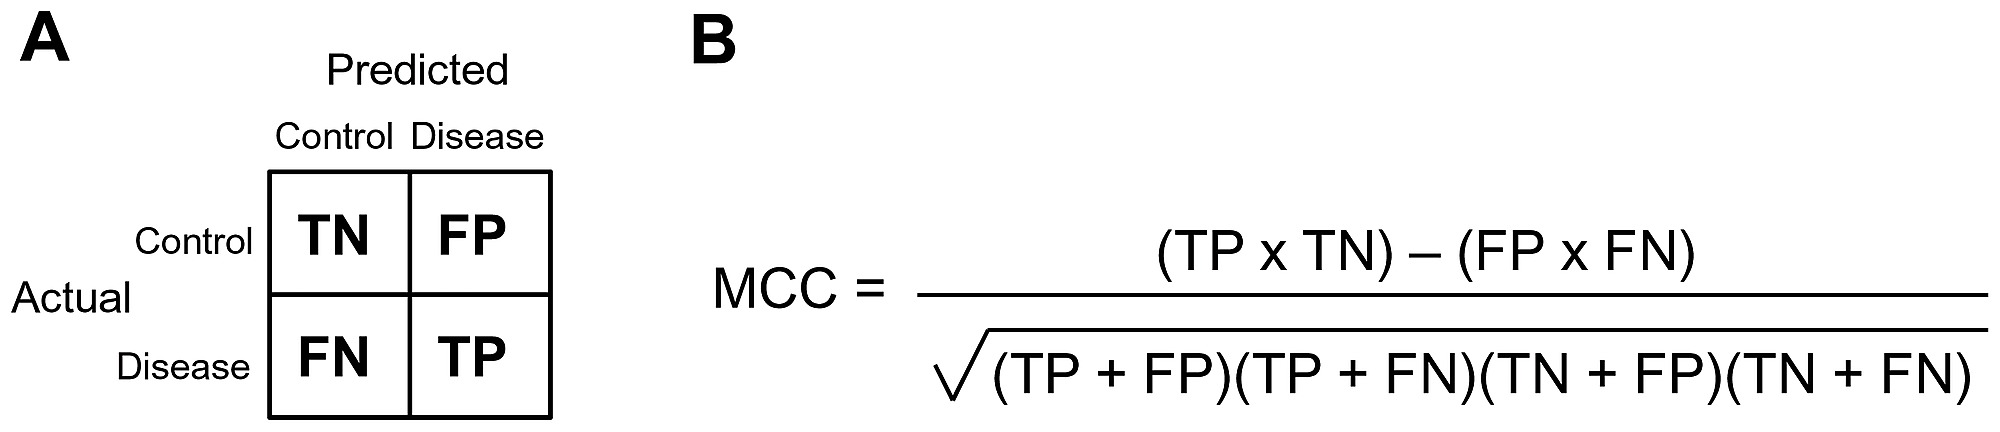

Наиболее сбалансированная метрика для оценки качества классификаторов, учитывающая все четыре компонента матрицы ошибок. MCC особенно полезен при сильном дисбалансе классов.



In [ ]:
from sklearn.metrics import matthews_corrcoef

In [ ]:
def build_dataset(tp, fp, fn, tn):
    y_true_pos = np.ones(tp + fn, dtype=int)
    y_pred_pos = np.array([1]*tp + [0]*fn, dtype=int)

    y_true_neg = np.zeros(fp + tn, dtype=int)
    y_pred_neg = np.array([1]*fp + [0]*tn, dtype=int)

    y_true = np.concatenate([y_true_pos, y_true_neg])
    y_pred = np.concatenate([y_pred_pos, y_pred_neg])
    return y_true, y_pred

In [ ]:
def report(name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[1, 0])
    f1 = f1_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)
    print(name)
    print("\nConfusion matrix [[TP FN],[FP TN]]:")
    print(cm)
    print(f"\nF1:  {f1:.3f}")
    print(f"MCC: {mcc:.3f}\n")

50 положительных (TP=30, FN=20) и 100 отрицательных (FP=10, TN=90)

In [ ]:
y_true_A, y_pred_A = build_dataset(tp=30, fp=10, fn=20, tn=90)
report("Вариант 1 (мало отрицательных)", y_true_A, y_pred_A)

Вариант 1 (мало отрицательных)

Confusion matrix [[TP FN],[FP TN]]:
[[30 20]
 [10 90]]

F1:  0.667
MCC: 0.533



50 положительных те же (TP=30, FN=20), но отрицательных очень много (FP=10, TN=9990)

In [ ]:
y_true_B, y_pred_B = build_dataset(tp=30, fp=10, fn=20, tn=9990)
report("Вариант 2 (очень много отрицательных)", y_true_B, y_pred_B)

Вариант 2 (очень много отрицательных)

Confusion matrix [[TP FN],[FP TN]]:
[[  30   20]
 [  10 9990]]

F1:  0.667
MCC: 0.669



- В обоих случаях F1 = 0.667, так как F1 зависит только от TP, FP и FN
- MCC во втором варианте выше, потому что при огромном числе отрицательных примеров модель сохраняет низкую долю FP, и эта информация учитывается в MCC


### AUC ROC – площадь под ROC-кривой

Показывает долю ложно положительных примеров (false positive rate) в сравнении с долей истинно положительных примеров (англ. true positive rate).

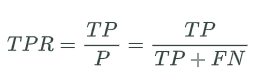

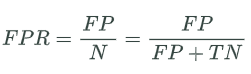

Если точнее - метрика измеряет, насколько хорошо модель ранжирует положительные случаи по сравнению с отрицательными.

Изменение порога изменяет показатели истинно положительных и ложноположительных результатов. Построение графика этих показателей друг относительно друга дает ROC-кривую, а ее площадь суммирует ранжирование модели по пороговым значениям.

#### Построение

[AUC ROC (площадь под кривой ошибок](https://alexanderdyakonov.wordpress.com/2017/07/28/auc-roc-%D0%BF%D0%BB%D0%BE%D1%89%D0%B0%D0%B4%D1%8C-%D0%BF%D0%BE%D0%B4-%D0%BA%D1%80%D0%B8%D0%B2%D0%BE%D0%B9-%D0%BE%D1%88%D0%B8%D0%B1%D0%BE%D0%BA/)

* Пусть алгоритм выдал оценки, как показано в табл. 1.
* Упорядочим строки табл. 1 по убыванию ответов алгоритма – получим табл. 2.
* В идеале её столбец «класс» тоже станет упорядочен (сначала идут 1, потом 0); в самом худшем случае – порядок будет обратный (сначала 0, потом 1); в случае «слепого угадывания» будет случайное распределение 0 и 1.
* Чтобы нарисовать ROC-кривую, надо взять единичный квадрат на координатной плоскости, разбить его на m равных частей горизонтальными линиями и на n – вертикальными, где m – число 1 среди правильных меток теста (в нашем примере m=3), n – число нулей (n=4). В результате квадрат разбивается сеткой на m×n блоков.
* Будем просматривать строки табл. 2 сверху вниз и прорисовывать на сетке линии, переходя их одного узла в другой. Стартуем из точки (0, 0). Если значение метки класса в просматриваемой строке 1, то делаем шаг вверх; если 0, то делаем шаг вправо. Ясно, что в итоге мы попадём в точку (1, 1), т.к. сделаем в сумме m шагов вверх и n шагов вправо.

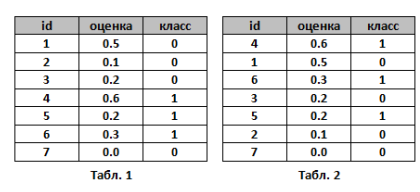

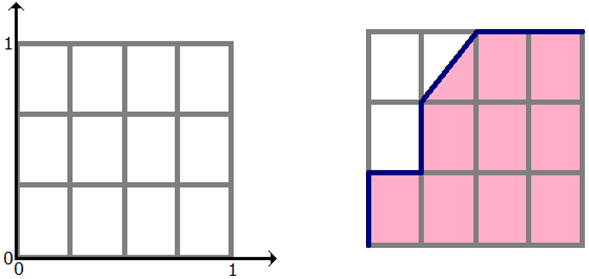

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

In [ ]:
def plot_roc_auc(fpr, tpr, thresholds, title):
  plt.plot([0,1], [0,1], linestyle='--', label='No Skill')
  plt.plot(fpr, tpr, marker='.', label='Logistic')
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.legend()
  plt.grid()
  plt.show()

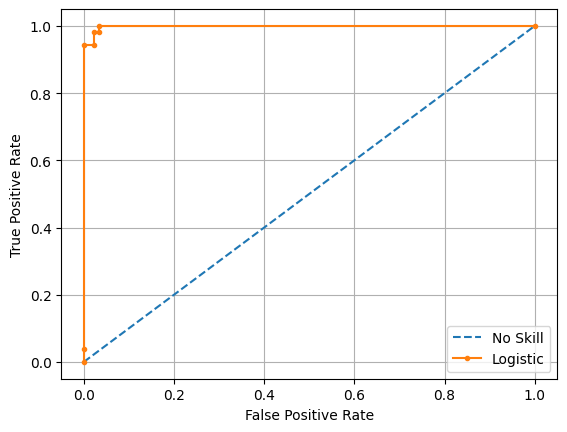

In [ ]:
y_pred = log_reg.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
plot_roc_auc(fpr, tpr, thresholds, title='Logistic regression')

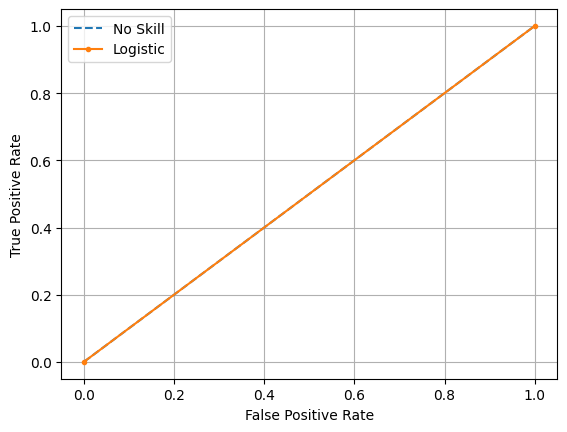

In [ ]:
y_pred = dummy_clf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
plot_roc_auc(fpr, tpr, thresholds, title='Dummy')

In [ ]:
class_fpr, class_tpr, class_roc_thresholds = roc_curve(y_test, y_pred)
roc_summary = pd.Series({"logistic_ROC_AUC": roc_auc_score(y_test, y_pred), "dummy_ROC_AUC": roc_auc_score(y_test, y_pred_dummy)})
roc_summary

,0
logistic_ROC_AUC,0.998532
dummy_ROC_AUC,0.500000


Чем лучше классификатор разделяет два класса, тем больше площадь (area under curve) под ROC-кривой – и мы можем использовать её в качестве метрики.

**NB**

- При сильном дисбалансе (например, 1% положительных) общий объём отрицательных примеров огромен. Даже если модель генерирует тысячи ложноположительных срабатываний, FPR может оставаться низким (FP относительно TN великого множества остаётся незначительным)

- Высокий AUC (например, 0.95) лишь показывает, что по среднему порогу TPR опережает FPR. Но на практических порогах (где бизнесу важно контролировать FP) модель может давать неприемлемое число ложных тревог

**Пример**

Допустим, в задаче банковского скоринга есть 100.000 заявок, из них 1.000 (1%) фродовые.

Модель имеет хорошую разделяющую способность, но в проде при выбранном пороге классификации оказалось, что TPR = 0.90 (обнаруживает 900 мошенников), FPR = 0.02 (ошибочно отклоняет 2.000 нормальных заявок), что может быть неприемлемо, но ROC-AUC этого может не показать

### PR-AUC – Precision-Recall кривая

PR-кривая объединяет решения при разных порогах на плоскости recall/precision.

Каждое пороговое значение дает пару значений: какую долю фактически положительных результатов модель обнаруживает и какую долю ее положительных прогнозов являются правильными. Построение графика зависимости точности от полноты дает кривую PR; PR AUC измеряет площадь под ней.


In [ ]:
from sklearn.metrics import average_precision_score, auc

In [ ]:
class_ap = average_precision_score(y_test, y_pred)
class_ap

np.float64(0.9975784091572628)

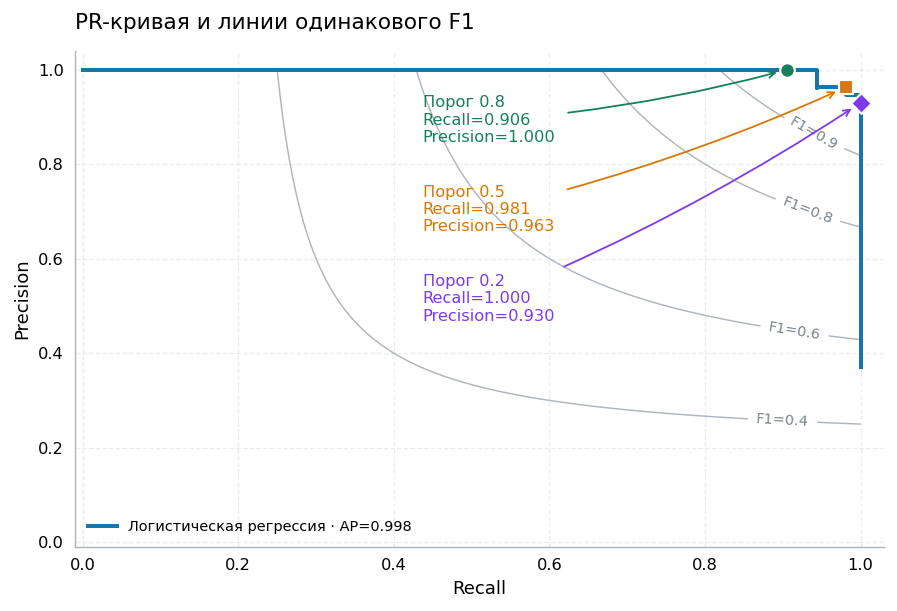

In [ ]:
y_true = np.asarray(y_test)
y_score = np.asarray(y_pred)

class_precision, class_recall, _ = precision_recall_curve(y_true, y_score)
class_ap = average_precision_score(y_true, y_score)

p_grid, r_grid = np.meshgrid(np.linspace(0.001, 1, 250), np.linspace(0.001, 1, 250))
f_grid = 2 * p_grid * r_grid / (p_grid + r_grid)

annotations = [
    (0.8, "#16805d", "o", (0.43, 0.86)),
    (0.5, "#d97706", "s", (0.43, 0.68)),
    (0.2, "#7c3aed", "D", (0.43, 0.50)),
]

with plt.style.context("default"):
    fig, ax = plt.subplots(figsize=(7, 4.8), dpi=130)

    contours = ax.contour(r_grid, p_grid, f_grid, levels=[0.4, 0.6, 0.8, 0.9], colors="#aeb5bd", linewidths=0.8, zorder=1)
    contour_labels = ax.clabel(contours, fmt="F1=%.1f", fontsize=8)

    for label in contour_labels:
        label.set_color("#7b8490")

    ax.step(class_recall, class_precision, where="post", color="#1675a9", linewidth=2.2, label=f"Логистическая регрессия · AP={class_ap:.3f}", zorder=3)

    for threshold, color, marker, text_position in annotations:
        pred = (y_score >= threshold).astype(int)
        recall_value = recall_score(y_true, pred, zero_division=np.nan)
        precision_value = precision_score(y_true, pred, zero_division=np.nan)

        if not np.isfinite(recall_value) or not np.isfinite(precision_value):
            continue

        ax.scatter(recall_value, precision_value, s=65, marker=marker, color=color, edgecolor="white", linewidth=1.2, zorder=5)

        text = f"Порог {threshold:.1f}\nRecall={recall_value:.3f}\nPrecision={precision_value:.3f}"
        ax.annotate(text, xy=(recall_value, precision_value), xycoords="data", xytext=text_position, textcoords="axes fraction", ha="left", va="center", fontsize=9, color=color, arrowprops=dict(arrowstyle="->", color=color, linewidth=1, shrinkA=5, shrinkB=6, connectionstyle="arc3,rad=0.05"), zorder=6)

    ax.set(xlabel="Recall", ylabel="Precision", xlim=(-0.01, 1.03), ylim=(-0.01, 1.04))
    ax.set_title("PR-кривая и линии одинакового F1", loc="left", fontsize=12, pad=12)
    ax.set_xticks(np.linspace(0, 1, 6))
    ax.set_yticks(np.linspace(0, 1, 6))
    ax.tick_params(axis="both", labelsize=9, length=0, pad=6)

    ax.set_axisbelow(True)
    ax.grid(color="#dce1e6", linestyle="--", linewidth=0.7, alpha=0.6)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    for spine in ["bottom", "left"]:
        ax.spines[spine].set_color("#aeb5bd")

    ax.legend(loc="lower left", frameon=False, fontsize=8)

    plt.tight_layout()
    plt.show()

### Многоклассовая классификация - F1-мера

Если классов больше, чем 2, мы имеем дело с многоклассовой классификацией.

Если задача классификации на  классов ставится как  задач об отделении каждого класса  от остальных (one vs all), то для каждой из них можно посчитать свою матрицу ошибок. Затем есть два варианта получения итогового значения метрики из  матриц ошибок:

- **micro**: усредняем элементы матрицы ошибок (TP, FP, TN, FN) между бинарными классификаторами, например . Затем по одной усреднённой матрице ошибок считаем Precision, Recall, F-меру.

- **macro**: считаем Precision, Recall для каждого классификатора отдельно, а потом усредняем.

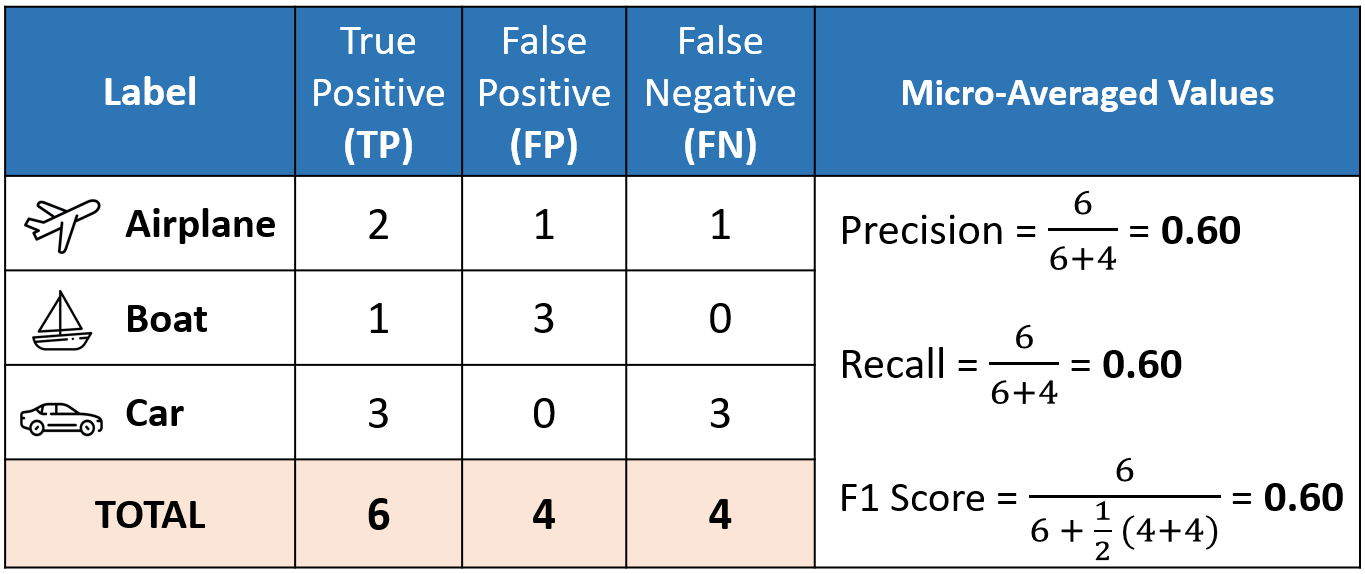

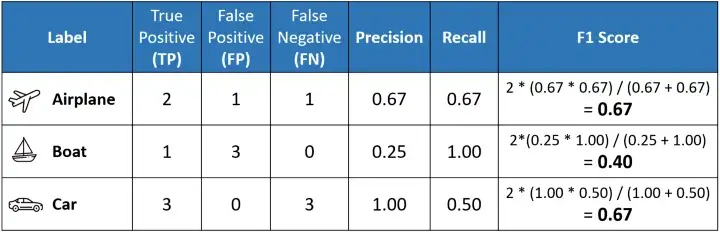

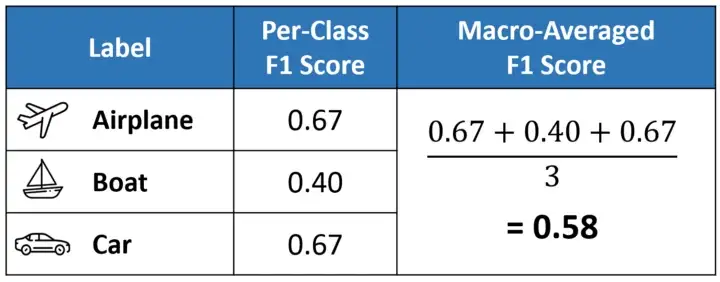

В случае дисбаланса классов способ усреднения может оказать существенное влияние: при макроусреднении все классы вносят одинаковый вклад, при микроусреднении минорные классы не влияют на метрику

### Примеры критических эффектов неправильного выбора метрик и их интерпретации

#### Кейс 1 (Fraud Detection)



Банк внедрил систему детекции мошенничества с accuracy 99%. Звучит отлично? Но fraud составляет только 0.5% транзакций. Модель просто предсказывает "не мошенничество" для всех случаев. Продуктовый эффект: пропущено 100% мошеннических транзакций, убытки миллионы долларов.



#### Кейс 2 (Recommendation System)

E-commerce платформа оптимизировала рекомендательную систему на precision 0.95. Продуктовый эффект: система показывает только очевидные товары, которые пользователь и так купил бы. Низкий recall = упущенные продажи новых категорий, снижение average order value на 15%.

#### Кейс 3 (Medical Diagnosis)





Система диагностики рака с F1-score 0.87 была запущена в продакшн. Продуктовый эффект: высокий recall (находит большинство случаев) + низкий precision = огромное число ложных тревог, перегрузка врачей, потеря доверия к системе, отток клиентов клиники.